## 1) Calculations in AiiDAlab (with LSMO)

For adsorption studies, AiiDAlab provides automated workflows such as:

1. **Gas adsorption isotherms**  
   - Grand Canonical Monte Carlo (GCMC) simulations to compute uptake as a function of pressure and temperature.

2. **Henry’s coefficients**  
   - Low-pressure adsorption constants, useful for estimating selectivity.

3. **Pore analysis**  
   - Helium void fraction, accessible pore volume, and surface area to characterize adsorption capacity.

4. **Density calculations**  
   - Determination of framework or surface density, providing a structural descriptor linked to adsorption performance.

These tools can be applied both to porous frameworks and to surfaces like **LSMO**, supporting adsorption studies across materials classes.


2) We performed a pore analysis of IRMOF-1, with a probe radius of 1.525 Angstrom. We obtained as follows:
density: 0.576983 g/cm^3
ASA_A^2: 3964.65 A^2
POAV: 13737.4 A^3
porosity or POAV_Volume_fraction: 0.77498

pk: 5

## 3) Henry coefficients
We performed isotherm calculations for both CO₂ and CH₄ at 300 K and obtained the Henry coefficients:

- **Henry coefficient CO₂** = 5.0 × 10⁻⁶ mol/kg/Pa  
  pK: 294

- **Henry coefficient CH₄** = 1.0 × 10⁻⁶ mol/kg/Pa  
  pK: 329

The Henry coefficients indicate the relative affinity of gases for the adsorbent at low pressures. At 300 K, CO₂ has a higher Henry coefficient than CH₄. This clearly shows that CO₂ molecules interact more strongly with the IRMOF-1 framework than CH₄ molecules. As a result, IRMOF-1 preferentially adsorbs CO₂ in the low-pressure regime, making it effective for separating CO₂ from CH₄ in mixtures such as biogas.

## 4) Pure Isotherms at 300K
 
pk: 373 (CO2), pk: 391 (CH4)

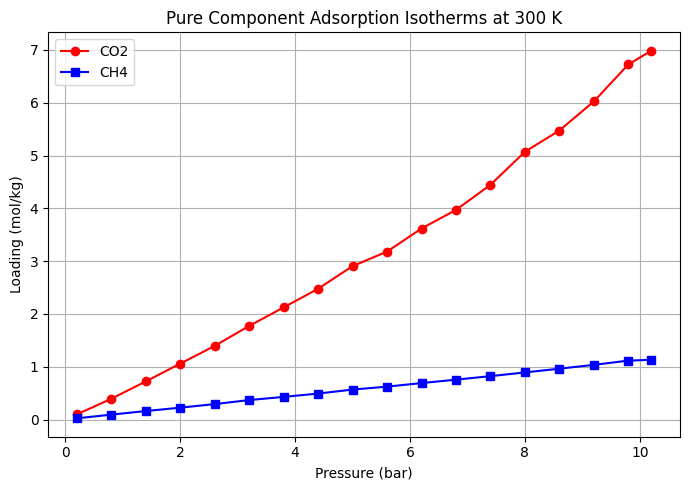

In [2]:
import matplotlib.pyplot as plt

# --- CO2 data ---
pressures_co2 = [0.2, 0.8, 1.4, 2.0, 2.6, 3.2, 3.8, 4.4, 5.0, 5.6, 6.2, 6.8, 7.4, 8.0, 8.6, 9.2, 9.8, 10.2]
loadings_co2 = [0.096723227554076, 0.39315949765796, 0.72151212791768, 1.0585987498258,
                1.394516510398, 1.7729353678762, 2.1233340216647, 2.4769795124972,
                2.9052697869712, 3.180276884598, 3.6175608976839, 3.9693881597718,
                4.4454069387926, 5.0707152850966, 5.4735178887752, 6.0242463881785,
                6.7247839487919, 6.985050406239]

# --- CH4 data ---
pressures_ch4 = [0.2, 0.8, 1.4, 2.0, 2.6, 3.2, 3.8, 4.4, 5.0, 5.6, 6.2, 6.8, 7.4, 8.0, 8.6, 9.2, 9.8, 10.2]
loadings_ch4 = [0.022050587171492, 0.09259979249488, 0.1602314081214, 0.22409669277688,
                0.29208546047824, 0.36825625753048, 0.4280954642514, 0.49127891312764,
                0.56676787440064, 0.62264593992788, 0.68988793510192, 0.75479220761868,
                0.82125496190936, 0.89164638902328, 0.96239496821204, 1.034929307775,
                1.1151856511322, 1.1304512536095]

# --- Plot both isotherms ---
plt.figure(figsize=(7,5))
plt.plot(pressures_co2, loadings_co2, marker="o", linestyle="-", color="red", label="CO2")
plt.plot(pressures_ch4, loadings_ch4, marker="s", linestyle="-", color="blue", label="CH4")

plt.xlabel("Pressure (bar)")
plt.ylabel("Loading (mol/kg)")
plt.title("Pure Component Adsorption Isotherms at 300 K")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## 5) Binary mixture isotherms

CH4 data shape: (26, 2)
CO2 data shape: (26, 2)
Pressure range: 21 points from 0.1 to 4.1000000000000005 bar

Calculating binary mixture isotherms using IAST...
                      Component 1: p^0 = 10.181943 > 10.100000, the highest pressure
                      exhibited in the pure-component isotherm data. Thus,
                      pyIAST had to extrapolate the isotherm data to achieve
                      this IAST result.
                      Component 1: p^0 = 10.794453 > 10.100000, the highest pressure
                      exhibited in the pure-component isotherm data. Thus,
                      pyIAST had to extrapolate the isotherm data to achieve
                      this IAST result.
                      Component 1: p^0 = 11.445850 > 10.100000, the highest pressure
                      exhibited in the pure-component isotherm data. Thus,
                      pyIAST had to extrapolate the isotherm data to achieve
                      this IAST result.
        

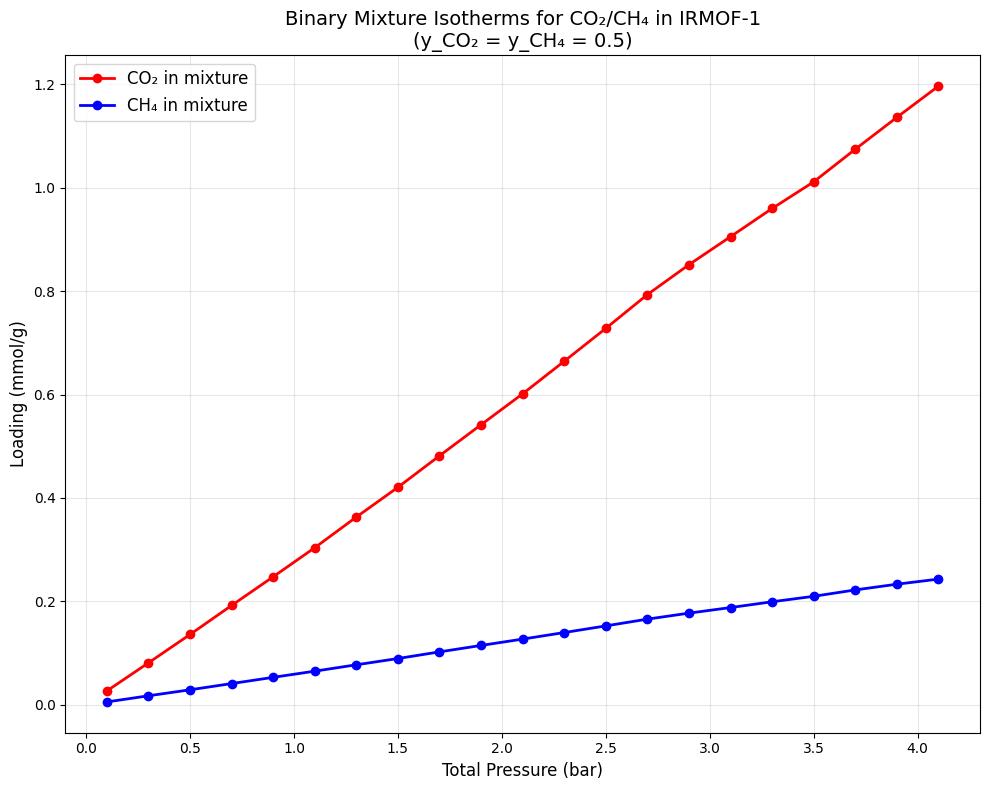

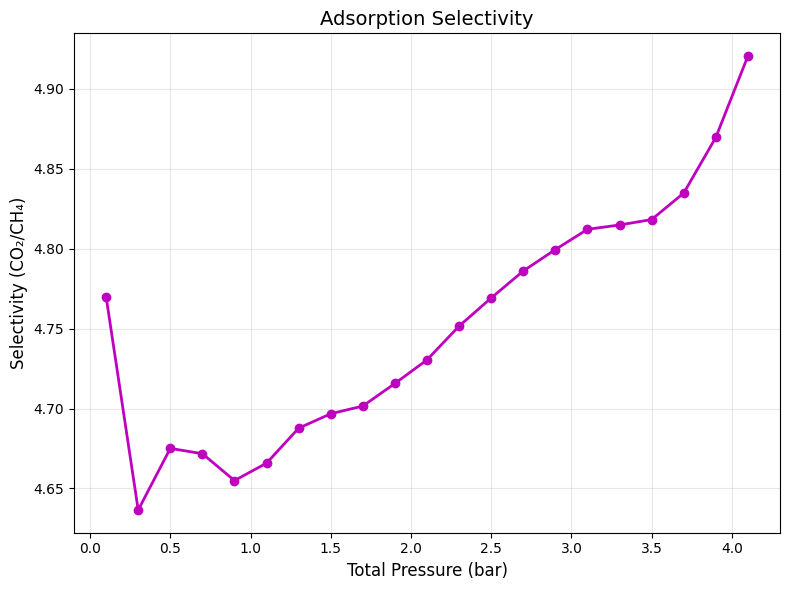


BINARY MIXTURE ISOTHERM RESULTS SUMMARY
Gas phase composition: y_CO₂ = 0.5, y_CH₄ = 0.5
Pressure range: 0.1 - 4.1000000000000005 bar
Number of pressure points: 21

First 10 data points:
   Pressure (bar)  CO₂ Loading (mmol/g)  CH₄ Loading (mmol/g)  \
0             0.1                0.0269                0.0056   
1             0.3                0.0812                0.0175   
2             0.5                0.1360                0.0291   
3             0.7                0.1922                0.0411   
4             0.9                0.2476                0.0532   
5             1.1                0.3038                0.0651   
6             1.3                0.3631                0.0775   
7             1.5                0.4206                0.0896   
8             1.7                0.4815                0.1024   
9             1.9                0.5416                0.1148   

   Total Loading (mmol/g)  Selectivity (CO₂/CH₄)  x_CO₂ (ads)  x_CH₄ (ads)  
0                  0

In [4]:
import pyiast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the data (assuming the CSV files are available)
df_ch4 = pd.read_csv("CH4_IRMOF1.csv")
df_co2 = pd.read_csv("CO2_IRMOF1.csv")

# Clean the data - remove unnamed columns and NaN values
df_ch4_clean = df_ch4[['Pressure(bar)', 'Loading(mmol/g)']].dropna()
df_co2_clean = df_co2[['Pressure(bar)', 'Loading(mmol/g)']].dropna()

print("CH4 data shape:", df_ch4_clean.shape)
print("CO2 data shape:", df_co2_clean.shape)

# Create interpolator isotherms for pure components
ch4_isotherm = pyiast.InterpolatorIsotherm(df_ch4_clean,
                                    loading_key="Loading(mmol/g)",
                                    pressure_key="Pressure(bar)",
                                    fill_value=df_ch4_clean["Loading(mmol/g)"].iloc[-1]  # plateau at max uptake
)

co2_isotherm = pyiast.InterpolatorIsotherm(df_co2_clean,
                                    loading_key="Loading(mmol/g)",
                                    pressure_key="Pressure(bar)",
                                    fill_value=df_co2_clean["Loading(mmol/g)"].iloc[-1]  # plateau at max uptake
)

# Define pressure range from 0.1 to 4.0 bar with increments of 0.2
pressures = np.arange(0.1, 4.2, 0.2)  # 4.2 to include 4.0
print(f"Pressure range: {len(pressures)} points from {pressures[0]} to {pressures[-1]} bar")

# Define gas mole fractions (50% each as specified)
y_co2 = 0.5  # CO2 mole fraction in gas phase
y_ch4 = 0.5  # CH4 mole fraction in gas phase

# Initialize arrays to store results
q_co2_mixture = []  # CO2 loading in mixture
q_ch4_mixture = []  # CH4 loading in mixture
q_total_mixture = []  # Total loading in mixture

print("\nCalculating binary mixture isotherms using IAST...")

# Calculate mixture isotherms using IAST
for P in pressures:
    try:
        # Calculate partial pressures
        p_co2 = y_co2 * P
        p_ch4 = y_ch4 * P
        
        partial_pressures = [p_co2, p_ch4]
        
        # Perform IAST calculation
        q_mixture = pyiast.iast(partial_pressures, 
                               [co2_isotherm, ch4_isotherm],
                               verboseflag=False)
        
        # Store results
        q_co2_mixture.append(q_mixture[0])  # CO2 loading
        q_ch4_mixture.append(q_mixture[1])  # CH4 loading
        q_total_mixture.append(q_mixture[0] + q_mixture[1])  # Total loading
        
    except Exception as e:
        print(f"Error at pressure {P} bar: {e}")
        q_co2_mixture.append(np.nan)
        q_ch4_mixture.append(np.nan)
        q_total_mixture.append(np.nan)

# Convert to numpy arrays
q_co2_mixture = np.array(q_co2_mixture)
q_ch4_mixture = np.array(q_ch4_mixture)
q_total_mixture = np.array(q_total_mixture)

# Create the main plot - Binary Mixture Isotherms
plt.figure(figsize=(10, 8))

# Plot CO2 and CH4 mixture isotherms on single graph
plt.plot(pressures, q_co2_mixture, 'ro-', label='CO₂ in mixture', markersize=6, linewidth=2)
plt.plot(pressures, q_ch4_mixture, 'bo-', label='CH₄ in mixture', markersize=6, linewidth=2)

plt.xlabel('Total Pressure (bar)', fontsize=12)
plt.ylabel('Loading (mmol/g)', fontsize=12)
plt.title('Binary Mixture Isotherms for CO₂/CH₄ in IRMOF-1\n(y_CO₂ = y_CH₄ = 0.5)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Additional analysis plot - Selectivity
plt.figure(figsize=(8, 6))
selectivity = q_co2_mixture / q_ch4_mixture
plt.plot(pressures, selectivity, 'mo-', markersize=6, linewidth=2)
plt.xlabel('Total Pressure (bar)', fontsize=12)
plt.ylabel('Selectivity (CO₂/CH₄)', fontsize=12)
plt.title('Adsorption Selectivity', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate mole fractions in adsorbed phase for results table
x_co2_ads = q_co2_mixture / (q_co2_mixture + q_ch4_mixture)
x_ch4_ads = q_ch4_mixture / (q_co2_mixture + q_ch4_mixture)

# Print summary results
print("\n" + "="*60)
print("BINARY MIXTURE ISOTHERM RESULTS SUMMARY")
print("="*60)
print(f"Gas phase composition: y_CO₂ = {y_co2}, y_CH₄ = {y_ch4}")
print(f"Pressure range: {pressures[0]} - {pressures[-1]} bar")
print(f"Number of pressure points: {len(pressures)}")

# Create summary table
results_df = pd.DataFrame({
    'Pressure (bar)': pressures,
    'CO₂ Loading (mmol/g)': q_co2_mixture,
    'CH₄ Loading (mmol/g)': q_ch4_mixture,
    'Total Loading (mmol/g)': q_total_mixture,
    'Selectivity (CO₂/CH₄)': selectivity,
    'x_CO₂ (ads)': x_co2_ads,
    'x_CH₄ (ads)': x_ch4_ads
})

print("\nFirst 10 data points:")
print(results_df.head(10).round(4))

print(f"\nAt 1 bar:")
idx_1bar = np.argmin(np.abs(pressures - 1.0))
print(f"  CO₂ loading: {q_co2_mixture[idx_1bar]:.4f} mmol/g")
print(f"  CH₄ loading: {q_ch4_mixture[idx_1bar]:.4f} mmol/g")
print(f"  Total loading: {q_total_mixture[idx_1bar]:.4f} mmol/g")
print(f"  Selectivity: {selectivity[idx_1bar]:.2f}")

print(f"\nAt 4 bar:")
idx_4bar = -1  # Last point
print(f"  CO₂ loading: {q_co2_mixture[idx_4bar]:.4f} mmol/g")
print(f"  CH₄ loading: {q_ch4_mixture[idx_4bar]:.4f} mmol/g")
print(f"  Total loading: {q_total_mixture[idx_4bar]:.4f} mmol/g")
print(f"  Selectivity: {selectivity[idx_4bar]:.2f}")

print(f"\nAverage selectivity over pressure range: {np.nanmean(selectivity):.2f}")
print(f"Maximum selectivity: {np.nanmax(selectivity):.2f} at {pressures[np.nanargmax(selectivity)]:.1f} bar")